In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("Online Retail.xlsx", engine='openpyxl')

print(df.shape)

(541909, 8)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
snapshot_date = df['InvoiceDate'].max()

In [9]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [6]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


In [7]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [10]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,0.00
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [11]:
def segment(row):
    if row['Monetary'] > 1000:
        return 'High Value'
    elif row['Recency'] > 30:
        return 'At Risk'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [12]:
rfm['Segment'].value_counts()

Segment
At Risk       2007
High Value    1633
Regular        732
Name: count, dtype: int64

In [13]:
rfm.groupby('Segment')['Monetary'].sum()

Segment
At Risk        739698.183
High Value    7204060.501
Regular        356307.130
Name: Monetary, dtype: float64

In [16]:
import matplotlib.pyplot as plt

In [15]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 3.3 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.1 MB 3.3 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 3.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.1 MB 4.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 4.3 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 4.5 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 4.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 5.9 MB/s eta 0:00:00
   -----------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


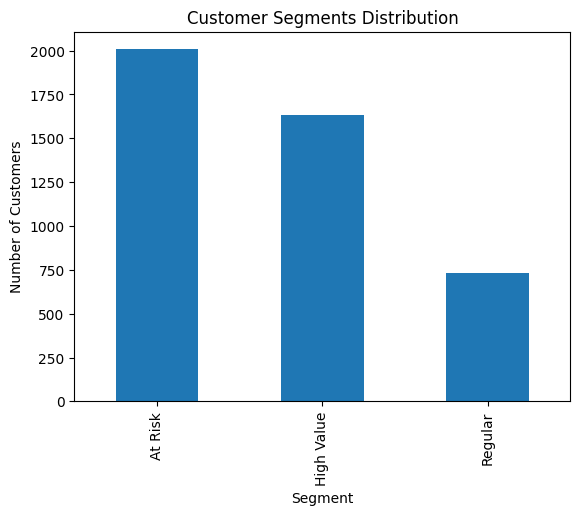

In [17]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

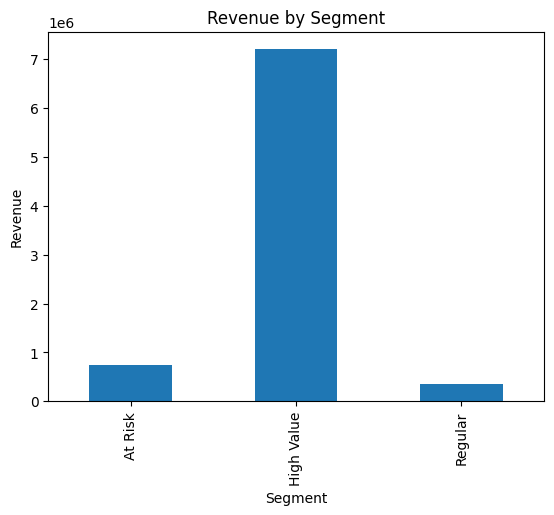

In [18]:
rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')
plt.title("Revenue by Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.show()

In [19]:
df.to_csv("data.csv", index=False)

In [20]:
df.to_csv("clean_data.csv", index=False)